# 3. Machine Learning for Classification

We'll use logistic regression to predict churn

# 3.1 Churn Prediction Project
- Dataset: [Kaggle](https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv)

# 3.2 Data preparation
- Download the data, read it with pandas
- Look at the data
- Make column names and values look uniform
- Check if all the columns read correctly
- Check if the churn variable needs any preparation

In [366]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [367]:
# Paths
base_path = Path.cwd()
file_path = base_path / "data" / "data.csv"
df = pd.read_csv(file_path)

In [368]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [369]:
df.dtypes[df.dtypes == 'str']

customerID          str
gender              str
Partner             str
Dependents          str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
TotalCharges        str
Churn               str
dtype: object

In [370]:
# replacing column names with lower caps and spaces with underscore in the column name
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [371]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


Column `totalcharges` should be integer.

In [372]:
df.totalcharges

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: totalcharges, Length: 7043, dtype: str

In [373]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [374]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [375]:
df.totalcharges = df.totalcharges.fillna(0)

In [376]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


### Target variable converted to `integer`

In [377]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [378]:
df.churn = (df.churn == 'yes').astype(int)

In [379]:
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

# 3.3 Setting up the validation framework

<div style="margin-left: 0; text-align: left; font-family: Arial, sans-serif;">

<h3>Dataset Split Workflow</h3>

<div style="display: flex; width: 720px; border: 2px solid black; height: 70px; margin-bottom: 20px;">
  <div style="width: 60%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 20%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>VAL (20%)</b>
  </div>
  <div style="width: 20%; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 1:</b> Split dataset into Train / Validation / Test</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; align-items: center; gap: 20px; margin-bottom: 20px;">
  <div style="width: 576px; border: 2px solid #1f77b4; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>FULL TRAIN = TRAIN + VAL (80%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 2:</b> After tuning on validation, merge Train + Validation into Full Train</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; gap: 20px; margin-bottom: 20px;">
  <div style="width: 432px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>VAL (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Inside Full Train:</b> Validation is <b>20% / 80% = 25%</b> of Full Train</p>

<hr style="margin: 20px 0;">

<p style="font-size: 16px;">
<b>Workflow:</b><br>
1. Train on <b>Train</b><br>
2. Tune on <b>Validation</b><br>
3. Retrain final model on <b>Full Train = Train + Validation</b><br>
4. Evaluate once on <b>Test</b>
</p>

</div>

- Perform the train/validation/test split with Scikit-Learn

In [380]:
from sklearn.model_selection import train_test_split

In [381]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [492]:
assert len(df) == (len(df_train) + len(df_val) + len(df_test))

In [382]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [383]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [384]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

# 3.4 EDA
- Check missing values
- Look at the target variable (churn)
- Look at numerical and categorical variables

In [385]:
df_full_train = df_full_train.reset_index(drop=True)

In [386]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [387]:
df_full_train.churn.value_counts(normalize=True) # as a percentage of the total

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [388]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [389]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [390]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [391]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [392]:
df_full_train[categorical].nunique() 

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

# 3.5 Feature importance: Churn rate and risk ratio
Feature importance analysis (part of EDA) - identifying which features affect our target variable

- Churn rate
- Risk ratio
- Mutual information - later

### Churn rate

#### Difference Method

difference = global - group

```mermaid
flowchart LR
    A[Global] --> C[Global - Group]
    B[Group] --> C

    C --> D{Result}

    D -->|< 0| E[More likely to churn]
    D -->|> 0| F[Less likely to churn]
```

In [393]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [394]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male, churn_female

(np.float64(0.2632135306553911), np.float64(0.27682403433476394))

In [395]:
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [396]:
df_full_train.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [397]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [398]:
global_churn_rate - churn_partner

np.float64(0.06493474245795922)

In [399]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [400]:
global_churn_rate - churn_no_partner

np.float64(-0.05984095297455855)


### Risk Ratio

$
\text{risk ratio} = \frac{\text{group}}{\text{global}}
$

```mermaid
flowchart LR
    A[Group Churn Rate] --> C["risk ratio = group / global"]
    B[Global Churn Rate] --> C

    C --> D{Result}

    D -->|> 1| E[More likely to churn]
    D -->|< 1| F[Less likely to churn]
    D -->|= 1| G[Same as global churn]
```

### Interpretation

| Risk Ratio | Meaning | Interpretation |
|:--|:--|:--|
| $\frac{\text{group}}{\text{global}} > 1$ | Group churn is higher than global churn | **More likely to churn** |
| $\frac{\text{group}}{\text{global}} < 1$ | Group churn is lower than global churn | **Less likely to churn** |
| $\frac{\text{group}}{\text{global}} = 1$ | Group churn equals global churn | **Same as average** |

### Example

If:

- Group churn rate = $0.35$
- Global churn rate = $0.27$

Then:

$
\text{risk ratio} = \frac{0.35}{0.27} \approx 1.30
$

Since:

$
\text{risk ratio} > 1
$

this group is:

$
\textbf{more likely to churn}
$

In [401]:
churn_no_partner / global_churn_rate

np.float64(1.2216593879412643)

In [402]:
churn_partner / global_churn_rate

np.float64(0.7594724924338315)

SELECT
    gender,
    AVG(churn),
    AVG(churn) - global_churn AS diff,
    AVG(churn) / global_churn AS risk
FROM
    data
GROUP BY
    gender;

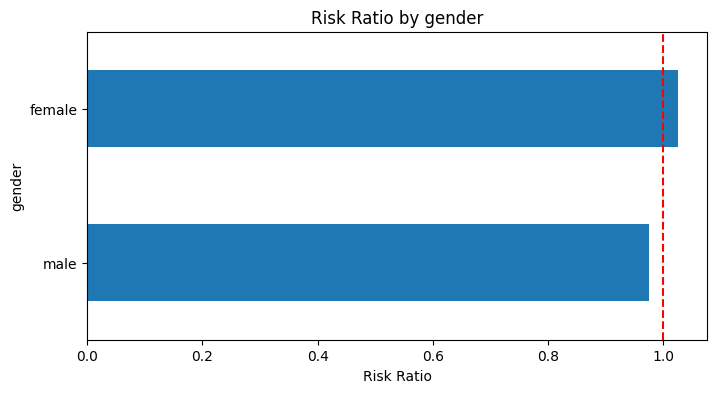

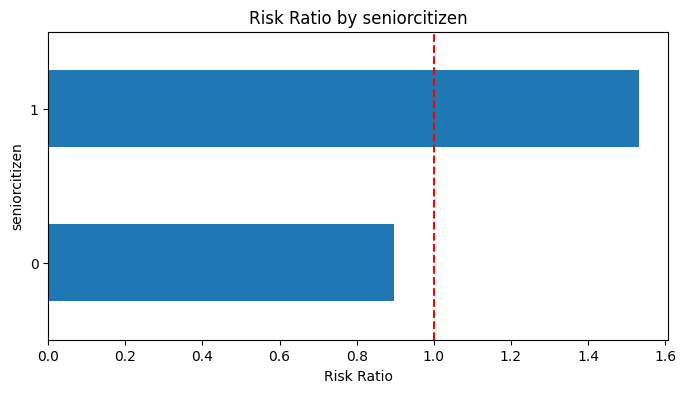

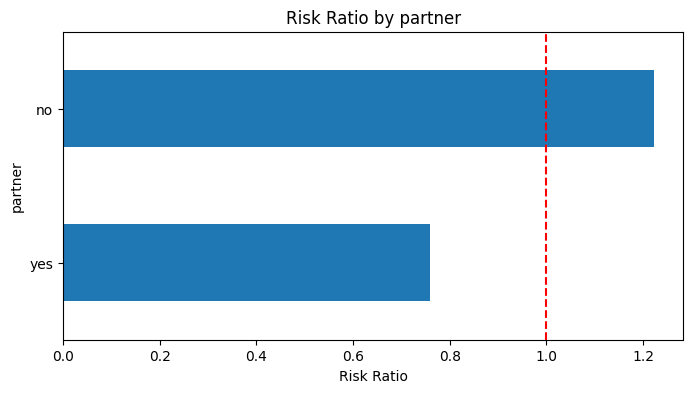

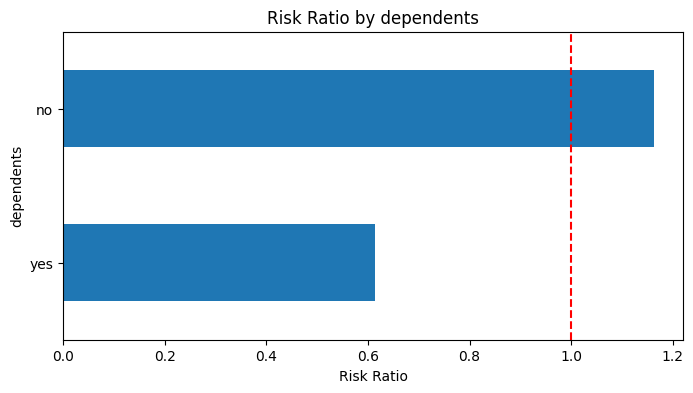

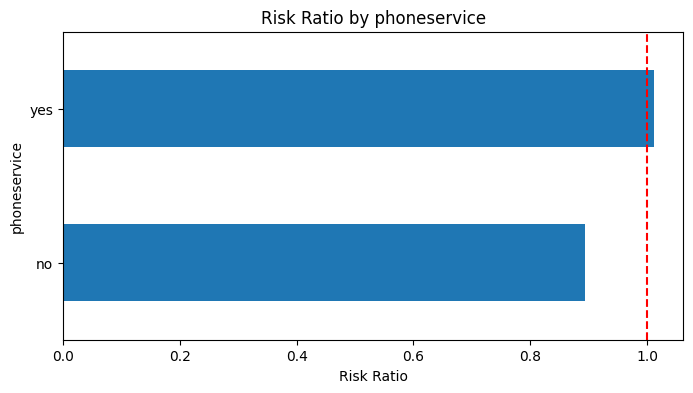

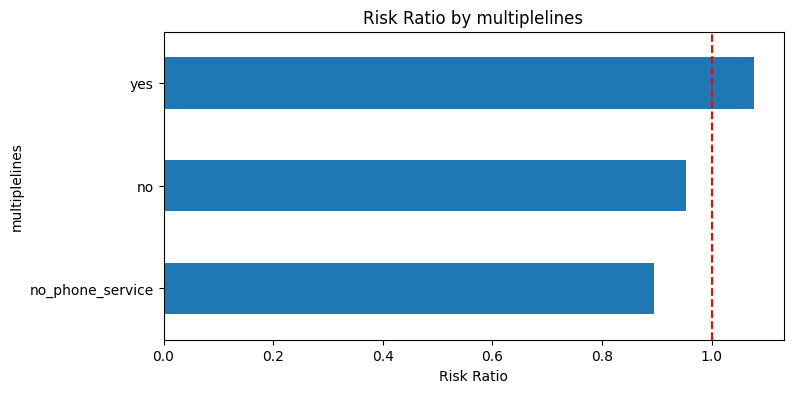

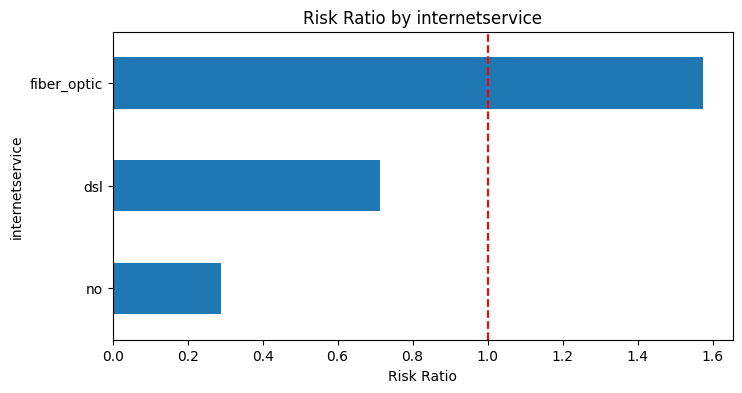

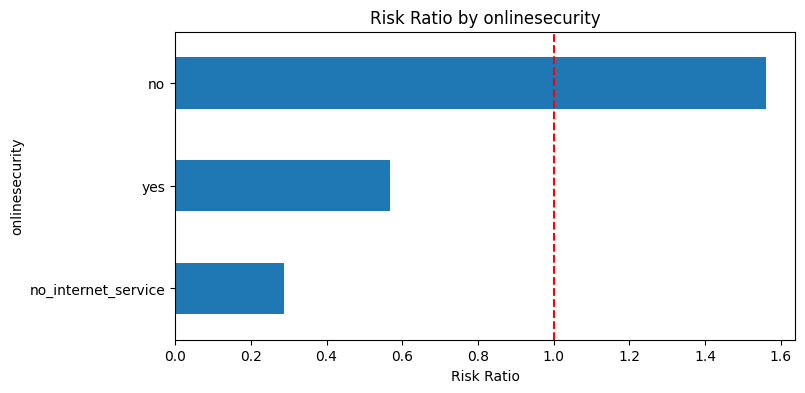

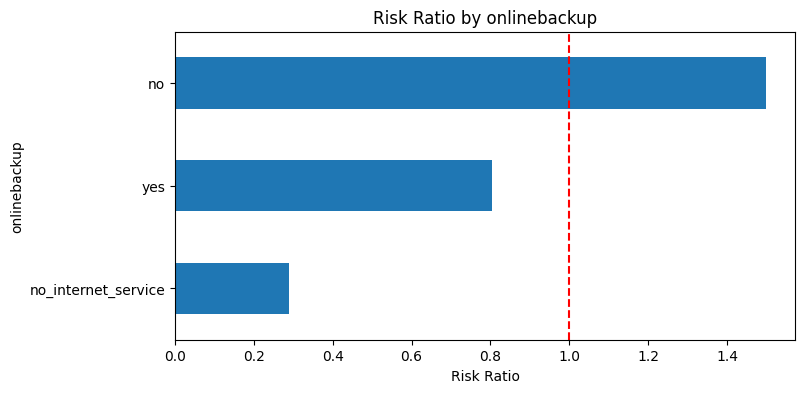

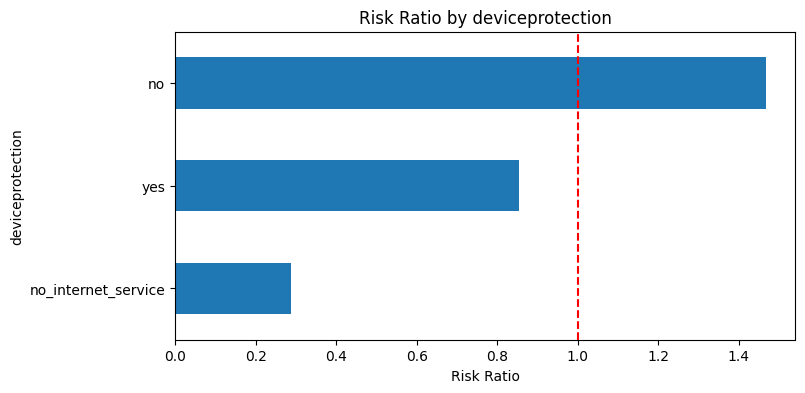

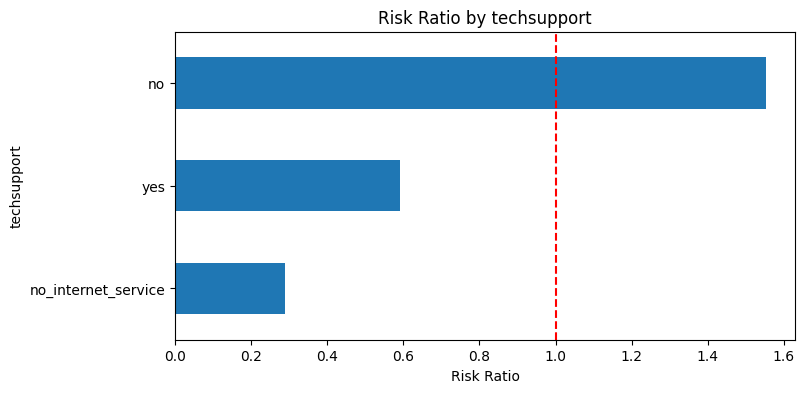

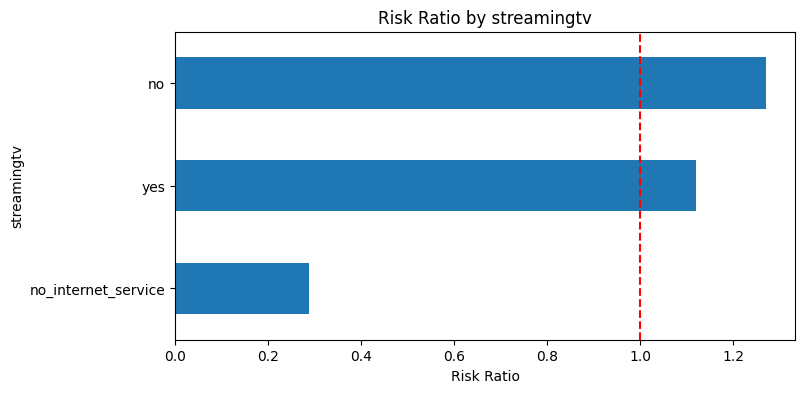

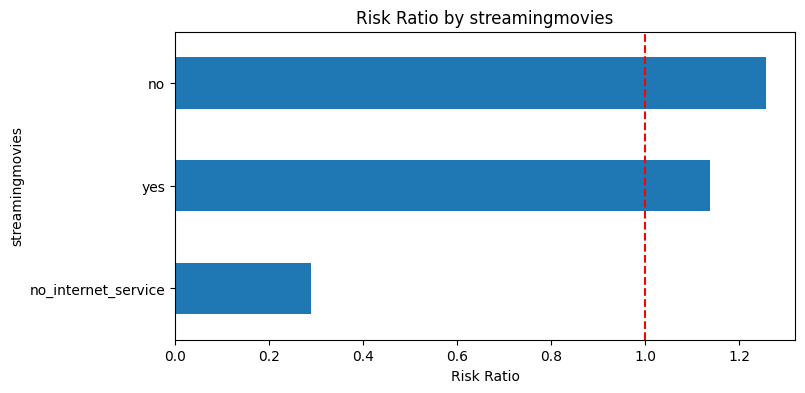

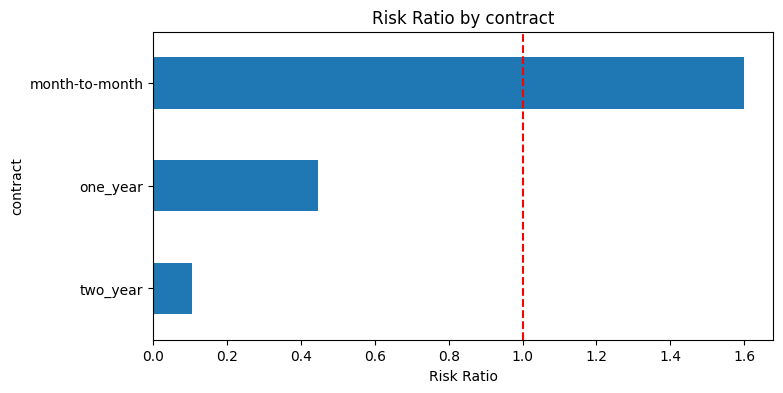

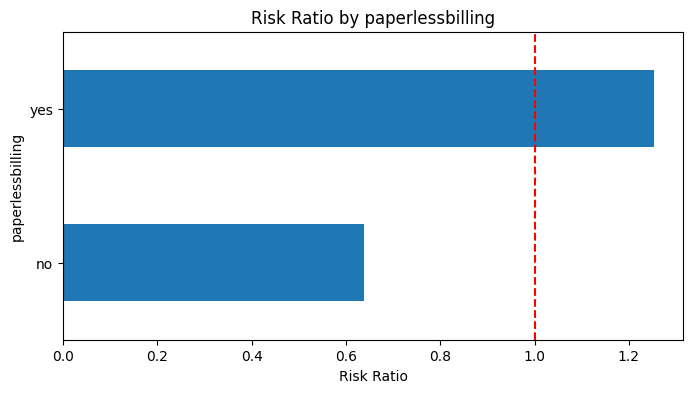

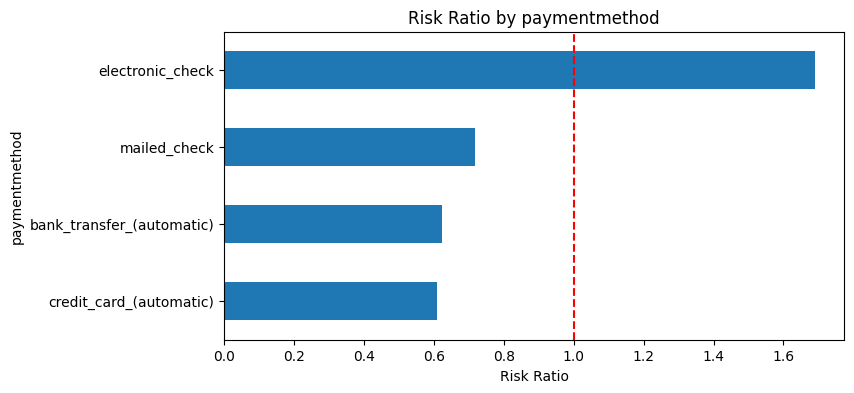

In [403]:
for c in categorical:
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['risk'] = df_group['mean'] / global_churn_rate
    df_group = df_group.sort_values('risk')

    df_group['risk'].plot(kind='barh', figsize=(8, 4), title=f'Risk Ratio by {c}')
    plt.axvline(1, color='red', linestyle='--')
    plt.xlabel('Risk Ratio')
    plt.show()

# 3.6 Feature importance: Mutual information (categorical variables)
Mutual information - concept from information theory, it tells us how much we can learn about one variable if we know the value of another

 - https://en.wikipedia.org/wiki/Mutual_information

In [404]:
from sklearn.metrics import mutual_info_score

In [405]:
df_full_train.dtypes[df_full_train.dtypes == 'str'].index

Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod'],
      dtype='str')

In [406]:
mutual_info_score(df_full_train.churn, df_full_train.contract) # contract is informative

0.0983203874041556

In [407]:
mutual_info_score(df_full_train.gender, df_full_train.churn) # gender is less informative

0.0001174846211139946

In [408]:
mutual_info_score(df_full_train.partner, df_full_train.churn) # more important than gender, more info score

0.009967689095399745

In [409]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [410]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

# 3.7 Feature importance: Correlation
How about numerical columns?

- Correlation coefficient - https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

### Interpretation of Tenure vs Churn

The boxplot shows a clear separation between customers who churned and those who did not:

- Customers with **churn = 1** generally have **lower tenure**
- Customers with **churn = 0** generally have **higher tenure**
- The median tenure for non-churned customers is much higher than for churned customers

This suggests that **customers who stay longer are less likely to churn**, making **tenure** an important predictive feature for the churn model.

There is still some overlap between the two groups, so tenure alone does not fully explain churn, but it appears to be a **strong indicator**.

In [411]:
df_full_train[numerical].corrwith(df_full_train.churn) # negative tenure corr confirms the above box plots

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

### Tenure

<Axes: xlabel='churn', ylabel='tenure'>

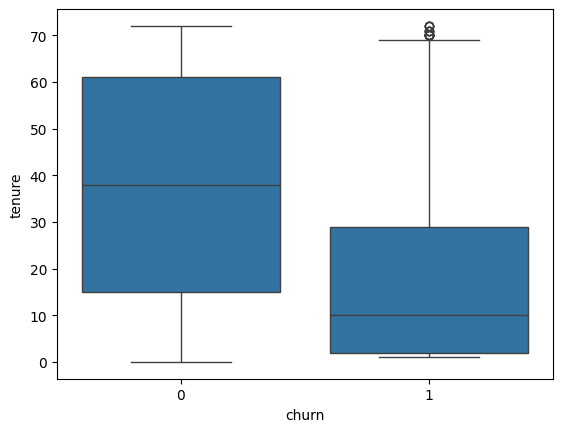

In [412]:
sns.boxplot(x='churn', y='tenure', data=df_full_train)

Negative correlation

In [413]:
df_full_train[df_full_train.tenure <= 2].churn.mean() # less than 2 months

np.float64(0.5953420669577875)

In [414]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean() # btwn 2-12months

np.float64(0.3994413407821229)

In [415]:
df_full_train[df_full_train.tenure > 12].churn.mean() # more than a year

np.float64(0.17634908339788277)

### Monthly Charges

<Axes: xlabel='churn', ylabel='monthlycharges'>

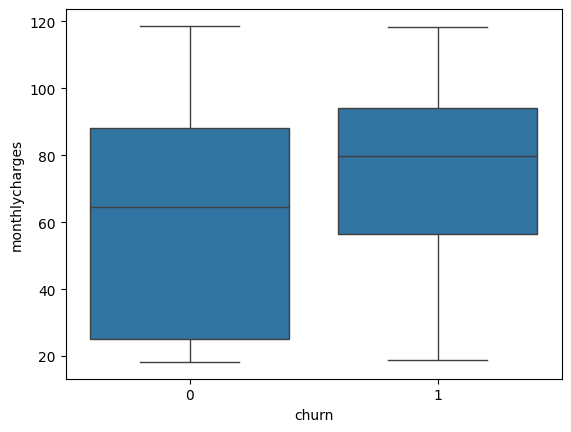

In [416]:
sns.boxplot(x='churn', y='monthlycharges', data=df_full_train)

Positive correlation

In [417]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [418]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [419]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

# 3.8 One-hot encoding
- Use Scikit-Learn to encode categorical features

In [420]:
from sklearn.feature_extraction import DictVectorizer

## One-Hot Encoding

One-hot encoding converts a categorical feature into multiple binary columns.

### Example: `contract`

```mermaid
flowchart LR
    A["contract = 'month-to-month'"] --> B["contract_month_to_month = 1"]
    A --> C["contract_one_year = 0"]
    A --> D["contract_two_year = 0"]
```

### Encoded Representation

| Original Value | contract_month_to_month | contract_one_year | contract_two_year |
|:--|--:|--:|--:|
| `month-to-month` | 1 | 0 | 0 |

### General Rule

For a categorical feature with possible values:

- `month-to-month`
- `one_year`
- `two_year`

we create:

- `contract_month_to_month`
- `contract_one_year`
- `contract_two_year`

Each row gets:

- **1** for the matching category
- **0** for all others

In [421]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [422]:
df_train[['gender', 'contract']].iloc[:100]

,gender,contract
0,female,two_year
1,male,month-to-month
2,female,month-to-month
3,female,month-to-month
4,female,two_year
...,...,...
95,male,one_year
96,female,month-to-month
97,male,month-to-month
98,male,one_year


In [423]:
df_train[['gender', 'contract', 'tenure']].iloc[:100].to_dict(orient='records') # row wise

[{'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 10},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 5},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 5},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 18},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 4},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 1},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 1},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 6},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 17},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 66},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 2},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 4},
 {'gender': 'male', 'contract': 'month-to

In [424]:
dicts = df_train[['gender', 'contract', 'tenure']].iloc[:100].to_dict(orient='records') 

In [425]:
dv = DictVectorizer(sparse=False) # sparse set to false to use np array matrix
dv.fit(dicts)
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male', 'tenure'],
      dtype=object)

In [426]:
dv.transform(dicts) # tenure is numerical, it stays the same and not transformed

array([[ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 10.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 0.,  0.,  1.,  1.,  0., 18.],
       [ 1.,  0.,  0.,  0.,  1.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  1.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  1.,  0.,  6.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 17.],
       [ 0.,  0.,  1.,  1.,  0., 66.],
       [ 1.,  0.,  0.,  1.,  0.,  2.],
       [ 1.,  0.,  0.,  1.,  0.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  1.,  0., 71.],
       [ 1.,  0.,  0.,  1.,  0., 32.],
       [ 0.,  1.,  0.,  0.,  1., 53.],
       [ 0.,  0.,  1.,  0.,  1., 56.],
       [ 1.,  0.,  0.,  0.,  1., 61.],
       [ 0.,  1.,  0.,  1.,  0., 41.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0.,  3.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  0

### Transform all the variables

In [489]:
train_dict = df_train[categorical + numerical].to_dict(orient='records') 
X_train = dv.fit_transform(train_dict) # does the fit then tranformation at once instead of 2 steps


val_dict = df_val[categorical + numerical].to_dict(orient='records')

# why tranform only, validation/test must use the same feature columns learned from train. 
# which is already fitted
X_val = dv.transform(val_dict) 

X_train.shape

(4225, 45)

## 3.9 Logistic Regression 

- Binary classification
- Linear vs logistic regression

Logistic Regression is a **binary classification** algorithm used to predict the probability of an event, such as **churn = 1** or **churn = 0**.

### 1. Linear Score

First, we compute a linear combination of the features:

$
z = w_0 + x_1 w_1 + x_2 w_2 + \dots + x_n w_n
$

or in vector form:

$
z = w_0 + x^T w
$

### 2. Sigmoid Function

The linear score is then passed through the **sigmoid** function to convert it into a probability between 0 and 1:

$
g(z) = \frac{1}{1 + e^{-z}}
$

```text
Probability
1.0 |                           ********
    |                       ****
    |                    ***
0.5 |------------------***------------------> z
    |               ***
    |           ****
0.0 |***********
```

- When $z \ll 0$, then $\hat{y} \approx 0$
- When $z = 0$, then $\hat{y} = 0.5$
- When $z \gg 0$, then $\hat{y} \approx 1$



### 3. Predicted Probability

The predicted probability of the positive class is:

$
\hat{y} = g(z)
$

So:

$
\hat{y} = \frac{1}{1 + e^{-(w_0 + x^T w)}}
$

### 4. Decision Rule

To convert probability into a class prediction:

- If $\hat{y} \geq 0.5$ → predict **1**
- If $\hat{y} < 0.5$ → predict **0**

### 5. Interpretation

- Output is a **probability**
- Useful for **binary outcomes**
- In churn prediction:
  - $\hat{y}$ close to **1** → customer is more likely to churn
  - $\hat{y}$ close to **0** → customer is less likely to churn

```mermaid
flowchart LR
    A[Input Features x] --> B["Linear Score: z = w0 + x^T w"]
    B --> C["Sigmoid: g(z) = 1 / (1 + e^(-z))"]
    C --> D["Predicted Probability: y_hat"]
    D --> E{Threshold 0.5}
    E -->|>= 0.5| F[Predict Churn = 1]
    E -->|< 0.5| G[Predict Churn = 0]
```

In [428]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [429]:
z = np.linspace(-7, 7, 51)
z

array([-7.0000000e+00, -6.7200000e+00, -6.4400000e+00, -6.1600000e+00,
       -5.8800000e+00, -5.6000000e+00, -5.3200000e+00, -5.0400000e+00,
       -4.7600000e+00, -4.4800000e+00, -4.2000000e+00, -3.9200000e+00,
       -3.6400000e+00, -3.3600000e+00, -3.0800000e+00, -2.8000000e+00,
       -2.5200000e+00, -2.2400000e+00, -1.9600000e+00, -1.6800000e+00,
       -1.4000000e+00, -1.1200000e+00, -8.4000000e-01, -5.6000000e-01,
       -2.8000000e-01,  8.8817842e-16,  2.8000000e-01,  5.6000000e-01,
        8.4000000e-01,  1.1200000e+00,  1.4000000e+00,  1.6800000e+00,
        1.9600000e+00,  2.2400000e+00,  2.5200000e+00,  2.8000000e+00,
        3.0800000e+00,  3.3600000e+00,  3.6400000e+00,  3.9200000e+00,
        4.2000000e+00,  4.4800000e+00,  4.7600000e+00,  5.0400000e+00,
        5.3200000e+00,  5.6000000e+00,  5.8800000e+00,  6.1600000e+00,
        6.4400000e+00,  6.7200000e+00,  7.0000000e+00])

In [430]:
sigmoid(10000) # any value can never be more than one

np.float64(1.0)

In [431]:
sigmoid(z)

array([9.11051194e-04, 1.20508423e-03, 1.59386223e-03, 2.10780106e-03,
       2.78699622e-03, 3.68423990e-03, 4.86893124e-03, 6.43210847e-03,
       8.49286285e-03, 1.12064063e-02, 1.47740317e-02, 1.94550846e-02,
       2.55807883e-02, 3.35692233e-02, 4.39398154e-02, 5.73241759e-02,
       7.44679452e-02, 9.62155417e-02, 1.23467048e-01, 1.57095469e-01,
       1.97816111e-01, 2.46011284e-01, 3.01534784e-01, 3.63547460e-01,
       4.30453776e-01, 5.00000000e-01, 5.69546224e-01, 6.36452540e-01,
       6.98465216e-01, 7.53988716e-01, 8.02183889e-01, 8.42904531e-01,
       8.76532952e-01, 9.03784458e-01, 9.25532055e-01, 9.42675824e-01,
       9.56060185e-01, 9.66430777e-01, 9.74419212e-01, 9.80544915e-01,
       9.85225968e-01, 9.88793594e-01, 9.91507137e-01, 9.93567892e-01,
       9.95131069e-01, 9.96315760e-01, 9.97213004e-01, 9.97892199e-01,
       9.98406138e-01, 9.98794916e-01, 9.99088949e-01])

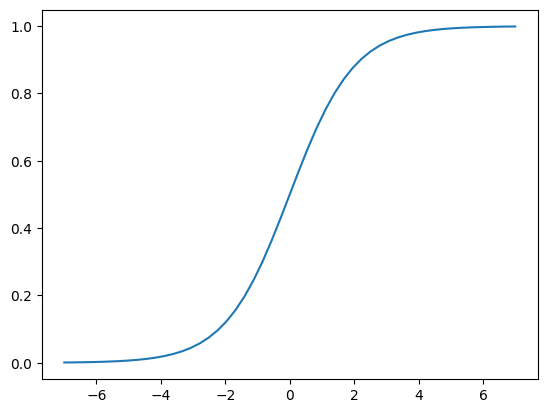

In [432]:
plt.plot(z, sigmoid(z))

In [433]:
def linear_regression(xi):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]
        
    return result

In [434]:
def logistic_regression(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]

    result = sigmoid(score)
    return result

# 3.10 Training logistic regression with Scikit-Learn
- Train a model with Scikit-Learn
- Apply it to the validation dataset
- Calculate the accuracy

In [435]:
from sklearn.linear_model import LogisticRegression

In [436]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\alann\anaconda3\envs\ml-zoomcamp-churn\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [437]:
model.intercept_[0]

np.float64(-0.10910575411731115)

In [438]:
model.coef_[0].round(3) # weights w

array([ 0.476, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.336,  0.317, -0.089,  0.004, -0.258,  0.142,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.059, -0.087, -0.032,  0.07 , -0.059,  0.142,
       -0.25 ,  0.216, -0.121, -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [439]:
model.predict(X_train) # result is binary(1s & 0s) as expected

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [440]:
model.predict_proba(X_train) # probability scores of R(YES) and LEFT(NO)

array([[0.90452492, 0.09547508],
       [0.32058285, 0.67941715],
       [0.36630247, 0.63369753],
       ...,
       [0.46766799, 0.53233201],
       [0.95761329, 0.04238671],
       [0.3012034 , 0.6987966 ]], shape=(4225, 2))

In [490]:
model.predict_proba(X_train)[:, 1] # only interested in the 2nd column, RHS (YES)

array([0.10135787, 0.69286472, 0.66541346, ..., 0.50589484, 0.04784231,
       0.73042676], shape=(4225,))

In [442]:
y_pred = model.predict_proba(X_val)[:, 1]

In [443]:
y_pred

array([0.00896799, 0.20454216, 0.21215178, ..., 0.1363222 , 0.79995367,
       0.83758207], shape=(1409,))

In [444]:
churn_decision = (y_pred >= 0.5) # decison threshold, recap decision rule in sigmoid function

In [445]:
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [446]:
df_val[churn_decision].customerid # people who will receive promotional email

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 312, dtype: str

In [447]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [448]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [449]:
(y_val == churn_decision).mean() # comparison of predicted vs actual

np.float64(0.8026969481902059)

### Visualizing in dataframe

In [450]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [451]:
df_pred

,probability,prediction,actual
0,0.008968,0,0
1,0.204542,0,0
2,0.212152,0,0
3,0.543024,1,1
4,0.213658,0,0
...,...,...,...
1404,0.313711,0,0
1405,0.039280,0,1
1406,0.136322,0,0
1407,0.799954,1,1


In [452]:
df_pred['correct'] = df_pred.prediction == df_pred.actual # labelling

In [453]:
df_pred

,probability,prediction,actual,correct
0,0.008968,0,0,True
1,0.204542,0,0,True
2,0.212152,0,0,True
3,0.543024,1,1,True
4,0.213658,0,0,True
...,...,...,...,...
1404,0.313711,0,0,True
1405,0.039280,0,1,False
1406,0.136322,0,0,True
1407,0.799954,1,1,True


In [454]:
df_pred.correct.mean() # model if correct in 80% of the cases

np.float64(0.8026969481902059)

# 3.11 Model interpretation
- Look at the coefficients
- Train a smaller model with fewer features

In [455]:
a = [1, 2, 3, 4]
b = 'abcd'

In [456]:
dict(zip(a, b))

{1: 'a', 2: 'b', 3: 'c', 4: 'd'}

In [457]:
dict( zip(dv.get_feature_names_out(), model.coef_[0].round(3)) )

{'contract=month-to-month': np.float64(0.476),
 'contract=one_year': np.float64(-0.175),
 'contract=two_year': np.float64(-0.408),
 'dependents=no': np.float64(-0.03),
 'dependents=yes': np.float64(-0.078),
 'deviceprotection=no': np.float64(0.063),
 'deviceprotection=no_internet_service': np.float64(-0.089),
 'deviceprotection=yes': np.float64(-0.081),
 'gender=female': np.float64(-0.034),
 'gender=male': np.float64(-0.073),
 'internetservice=dsl': np.float64(-0.336),
 'internetservice=fiber_optic': np.float64(0.317),
 'internetservice=no': np.float64(-0.089),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.258),
 'multiplelines=no_phone_service': np.float64(0.142),
 'multiplelines=yes': np.float64(0.009),
 'onlinebackup=no': np.float64(0.063),
 'onlinebackup=no_internet_service': np.float64(-0.089),
 'onlinebackup=yes': np.float64(-0.081),
 'onlinesecurity=no': np.float64(0.266),
 'onlinesecurity=no_internet_service': np.float64(-0.089),
 'onlinesecurity=yes'

#### Smaller protoptype model for initial testing

In [458]:
small = ['contract', 'tenure', 'monthlycharges']

In [459]:
df_train[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,72,115.50
1,month-to-month,10,95.25
2,month-to-month,5,75.55
3,month-to-month,5,80.85
4,two_year,18,20.10
5,month-to-month,4,30.50
6,month-to-month,1,75.10
7,month-to-month,1,70.30
8,two_year,72,19.75
9,month-to-month,6,109.90


In [461]:
dict_train_small = df_train[small].to_dict(orient='records')
dict_val_small = df_val[small].to_dict(orient='records')

In [462]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dict_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [463]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [464]:
X_train_small = dv_small.transform(dict_train_small)

In [465]:
model_small = LogisticRegression()
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [466]:
w0 = model_small.intercept_[0] # bias term
w0.round(3)

np.float64(-2.478)

In [467]:
w = model_small.coef_[0]
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [468]:
dict( zip(dv_small.get_feature_names_out(), w.round(3)) )

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [469]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

In [470]:
sigmoid(_)

np.float64(0.030090303318277657)

### Manual Calculation Prediction Example

For one customer, logistic regression computes the **log-odds score** first:

$
z = w_0 + x_1 w_1 + x_2 w_2 + \dots + x_n w_n
$

Using the values from the small model:

$
z = -2.47 + 1 \cdot 0.971 + 0 \cdot (-0.024) + 0 \cdot (-0.948) + 50 \cdot 0.027 + 5 \cdot (-0.036)
$


---

### Total linear score

$
z = -2.47 + 0.971 + 0 + 0 + 1.35 - 0.18
$

$
z = -3.473
$

---

### Convert score to probability using sigmoid

$
\large
\hat{y} = \frac{1}{1 + e^{-z}}
$

$
\large
\hat{y} = \frac{1}{1 + e^{-(-3.473)}} = \frac{1}{1 + e^{3.473}}
$

$
\large
\hat{y} \approx 0.030
$

---

## Interpretation

- Predicted **churn probability** = **0.03** (3%)
- Since:

$
\large
\hat{y} < 0.5
$

the model predicts:

$
\textbf{No Churn (0)}
$

### Meaning of the result

- This customer is **less likely to churn than to stay**
  

---

## Quick intuition from the coefficients

- **Month-to-month contract (+0.97)** → increases churn risk
- **Higher monthly charges (+0.027)** → increases churn risk
- **Longer tenure (-0.036)** → decreases churn risk
- **Two-year contract (-0.949)** → strongly reduces churn risk (if active)



# 3.12 Using the Model

In [471]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [472]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [473]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [474]:
y_full_train = df_full_train.churn.values

In [475]:
model = LogisticRegression()
model.fit(X_full_train, y_full_train)

C:\Users\alann\anaconda3\envs\ml-zoomcamp-churn\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [476]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')

In [477]:
X_test = dv.transform(dicts_test)

In [478]:
y_pred = model.predict_proba(X_test)[:, 1] # yes values column only

In [479]:
churn_decision = (y_pred >= 0.5)

In [480]:
(churn_decision == y_test).mean() # difference not huge from validation test, if difference is big not a good model

np.float64(0.8140525195173882)

In [481]:
y_test

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [482]:
customer = dicts_test[-1] # sample customer for prediction 
customer

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [483]:
X_small = dv.transform([customer])

In [484]:
model.predict_proba(X_small)[0, 1]

np.float64(0.6584201121103557)

In [485]:
y_test[-1] # customer likely to churn, send marketing email

np.int64(1)

# 3.13 Summary
- Feature importance - risk, mutual information, correlation
- One-hot encoding can be implemented with DictVectorizer
- Logistic regression - linear model like linear regression
- Output of log reg - probability
- Interpretation of weights is similar to linear regression